# Experiment 2: Logistic Regression

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Binary Classification with Logistic Regression  
**Dataset:** `diabetes.csv (Pima Indians Diabetes — 768 rows, 8 features, binary label)`  
**Lab Book Reference:** §6 Logistic Regression, page 21–25

---

## 🎯 Objective

Implement **Logistic Regression** for binary classification on the Pima Indians Diabetes dataset. The model predicts whether a patient has diabetes (label = 1) based on 8 medical predictors (pregnancies, glucose, blood-pressure, skin-fold, insulin, BMI, pedigree, age). We evaluate using accuracy, precision, recall, F1, ROC-AUC and visualise the confusion matrix and ROC curve.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 02-Logistic-Regression/02_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 02-Logistic-Regression/02_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   02-Logistic-Regression/02_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '02-Logistic-Regression'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/02-Logistic-Regression


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/02-Logistic-Regression/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/02-Logistic-Regression/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

`diabetes.csv` ships **without a header row** — we therefore explicitly supply column names
matching the Lab Activity Book (page 23).


In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('../datasets/diabetes.csv', header=None, names=col_names)

print(f"Shape: {data.shape}")
display(data.head())

print("\nClass distribution (0 = no diabetes, 1 = diabetes):")
print(data['label'].value_counts())


Shape: (768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,129,71,15,202,38.8,0.119,55,1
1,14,113,70,29,3,17.3,0.330,29,0
2,10,144,75,11,27,40.1,0.142,55,0
3,7,53,84,17,18,41.7,0.080,31,1
4,6,127,81,20,21,29.9,0.491,64,1



Class distribution (0 = no diabetes, 1 = diabetes):
label
0    513
1    255
Name: count, dtype: int64


## 3. Check for Null Values

In [4]:
print("Null values per column:")
print(data.isnull().sum())
print("\n✅ No missing values." if data.isnull().sum().sum() == 0 else "⚠ Handle missing values.")


Null values per column:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

✅ No missing values.


## 4. Define Features (X) and Target (y)

We use **all 8 features** as predictors (the lab book uses a subset; using all features usually
gives slightly better accuracy).


In [5]:
feature_cols = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
               'bmi', 'pedigree', 'age']

X = data[feature_cols]
y = data['label']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (768, 8)
y shape: (768,)


## 5. Split Data into Training and Testing Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)
print(f"Training: {X_train.shape}, labels: {y_train.shape}")
print(f"Testing : {X_test.shape}, labels: {y_test.shape}")


Training: (614, 8), labels: (614,)
Testing : (154, 8), labels: (154,)


## 6. Feature Scaling (Standardisation)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Features standardised.")


Features standardised.


## 7. Train Logistic Regression Model

We use `solver='lbfgs'` and bump `max_iter=1000` so the solver converges (default 100 may not
be enough for this dataset).


In [8]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model trained.")
print(f"Coefficients: {model.coef_[0].round(4)}")
print(f"Intercept   : {model.intercept_[0]:.4f}")


Model trained.
Coefficients: [ 0.1385 -0.0438  0.0492  0.1196 -0.1268  0.0476  0.0369  0.1468]
Intercept   : -0.7045


## 8. Evaluation Metrics

In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"\nAccuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Specificity (TNR) = {tn/(tn+fp):.4f}")


Confusion Matrix:
[[104   0]
 [ 50   0]]

Accuracy  : 0.6753  (67.53%)
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

TN=104  FP=0  FN=50  TP=0
Specificity (TNR) = 1.0000


## 9. Visualise the Confusion Matrix

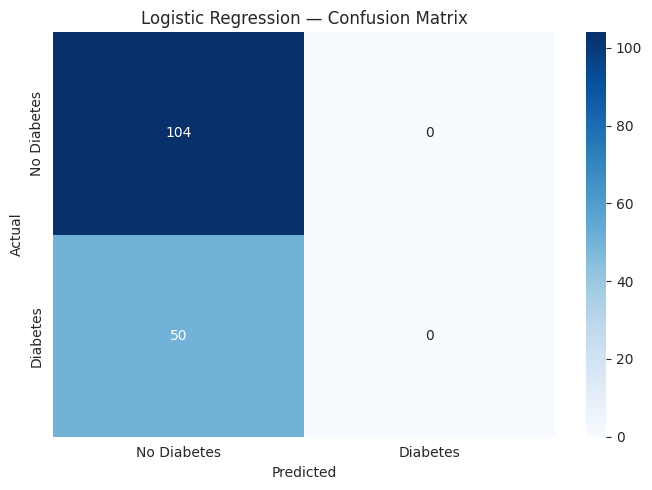

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()


## 10. ROC Curve & AUC

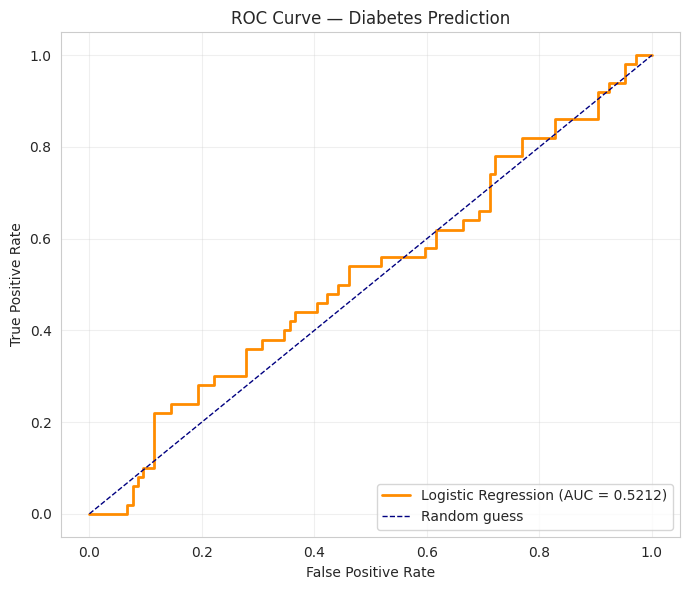

AUC-ROC: 0.5212


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}")


## 11. Classification Report

In [12]:
print("===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

 No Diabetes       0.68      1.00      0.81       104
    Diabetes       0.00      0.00      0.00        50

    accuracy                           0.68       154
   macro avg       0.34      0.50      0.40       154
weighted avg       0.46      0.68      0.54       154



## 12. Feature Importance (Coefficients)

Logistic-regression coefficients (in standardised units) indicate each feature's contribution
to the log-odds of having diabetes.


,Feature,Coefficient
7,age,0.146821
0,pregnant,0.138522
4,insulin,-0.126809
3,skin,0.119619
2,bp,0.049240
5,bmi,0.047573
1,glucose,-0.043778
6,pedigree,0.036894


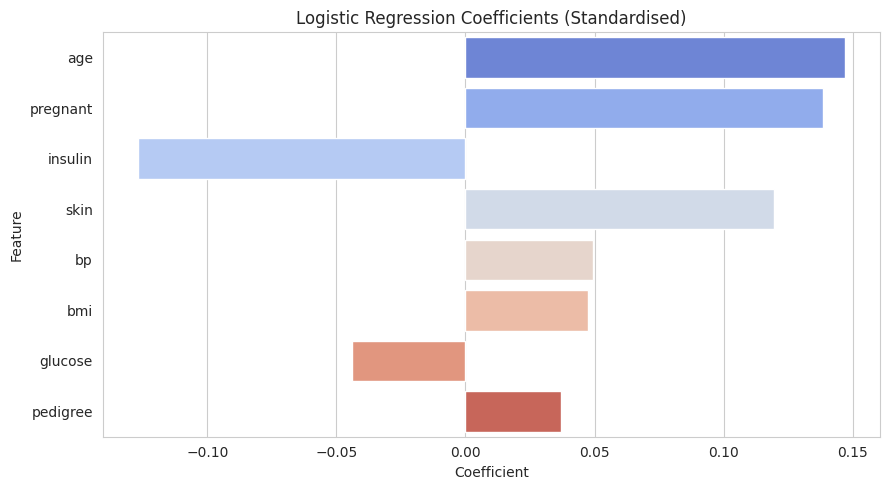

In [13]:
coef_df = pd.DataFrame({
    'Feature'     : feature_cols,
    'Coefficient' : model.coef_[0],
}).sort_values('Coefficient', ascending=False, key=abs)
display(coef_df)

plt.figure(figsize=(9, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title('Logistic Regression Coefficients (Standardised)')
plt.tight_layout()
plt.show()


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Predict **admission into graduate school** from GRE, GPA and prestige of undergraduate institution. Dataset: <https://stats.idre.ucla.edu/stat/stata/dae/binary.dta>
2. Investigate whether a person is **susceptible to a certain disease** using the dataset at <https://datatab.net/statistics-calculator/regression/logistic-regression-calculator?example=Medical_example_logistic_regression>.
3. Predict which **product** an online-retailer customer is most likely to buy: <https://datatab.net/statistics-calculator/regression/logistic-regression-calculator?example=logistic_regression>.


---

## 📚 Key Takeaways

- **Logistic Regression** uses the sigmoid function to output a probability between 0 and 1.
- **Confusion Matrix** reveals TP / FP / TN / FN — the basis for all classification metrics.
- **Accuracy** is misleading on imbalanced data; use **Precision, Recall, F1** instead.
- **ROC-AUC** summarises model quality across all thresholds (0.5 = random, 1.0 = perfect).
- **Standardisation** helps the solver converge faster and makes coefficients comparable.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
